# SPONGE Signed Spectral Diagnostic
## Tau Sensitivity, K-Selection, and Signed vs Unsigned Decomposition Analysis

Systematic diagnostic experiment analyzing why unsigned spectral clustering matches signed SPONGE on synthetic Co-Information (CoI) data. Five investigations:

1. **Tau sensitivity sweep** - grid search over regularization parameters
2. **K-selection analysis** - eigengap, silhouette, and stability strategies
3. **Decomposition analysis** - sign distribution, condition numbers, eigenvector similarity
4. **High-dimensional fix** - sparsification and threshold zeroing
5. **Final verdict** - root cause diagnosis and recommendations

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# joblib — NOT on Colab pre-installed list, always install
_pip('joblib==1.4.2')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# scipy 1.16.3 requires Python >=3.11; use 1.15.3 for Python 3.10 compat
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    _pip('scipy==1.15.3', 'scikit-learn==1.6.1')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/experiment_iter3_sponge_signed_s/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['variants'])} variants:")
for vname, vdata in data['variants'].items():
    d = vdata['meta']['n_features']
    k = len(vdata['meta']['ground_truth_modules'])
    print(f"  {vname}: d={d}, k={k}")

Loaded 4 variants:
  easy_2mod_xor: d=10, k=2
  medium_4mod_mixed: d=12, k=4
  hard_4mod_unequal: d=14, k=4
  highdim_8mod: d=20, k=8


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Tunable parameters — using full original values since our demo matrices are small.

RANDOM_STATE = 42

# Tau regularization values for sensitivity sweep (full original grid)
TAU_VALUES = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]

# K-selection parameters
N_BOOTSTRAP = 5                          # Original: 10 (reduced slightly for speed)
STABILITY_TIMEOUT = 30.0                 # Original: 120.0

# Highdim fix parameters (full original)
KEEP_FRACS = [0.05, 0.10, 0.20, 0.50]
LARGE_TAUS = [1.0, 5.0, 10.0, 50.0, 100.0]
THRESHOLDS = [0.001, 0.005, 0.01, 0.02, 0.05]

# Which variants to process
VARIANT_ORDER = list(data['variants'].keys())
STRUCTURED_VARIANTS = VARIANT_ORDER  # All our demo variants have structure

## Core Functions: SPONGE Signed & Unsigned Spectral Clustering

The SPONGE (Signed Positive over Negative Generalized Eigenproblem) algorithm splits the CoI matrix into positive and negative parts and solves a generalized eigenvalue problem. The unsigned baseline uses standard spectral clustering on |CoI|.

In [6]:
def _safe_inv_sqrt(d_vec):
    out = np.zeros_like(d_vec)
    mask = d_vec > 1e-10
    out[mask] = 1.0 / np.sqrt(d_vec[mask])
    return out


def _build_sponge_matrices(CoI, tau_p=1.0, tau_n=1.0):
    """Build SPONGE_sym generalised eigenvalue matrices.
    Negates CoI so synergistic features (negative CoI) become positive edges.
    """
    d = CoI.shape[0]
    signed_adj = -CoI

    A_pos = np.maximum(signed_adj, 0)
    A_neg = np.maximum(-signed_adj, 0)

    d_pos = A_pos.sum(axis=1)
    d_neg = A_neg.sum(axis=1)

    D_pos_inv = np.diag(_safe_inv_sqrt(d_pos))
    D_neg_inv = np.diag(_safe_inv_sqrt(d_neg))

    L_pos = np.diag(d_pos) - A_pos
    L_neg = np.diag(d_neg) - A_neg

    L_sym_pos = D_pos_inv @ L_pos @ D_pos_inv
    L_sym_neg = D_neg_inv @ L_neg @ D_neg_inv

    A_mat = L_sym_pos + tau_n * np.eye(d)
    B_mat = L_sym_neg + tau_p * np.eye(d)
    B_mat += 1e-10 * np.eye(d)

    return A_mat, B_mat


def sponge_sym(CoI, k, tau_p=1.0, tau_n=1.0, ridge=1e-10):
    """SPONGE_sym signed spectral clustering. Returns (labels, eigenvalues)."""
    d = CoI.shape[0]
    k = max(2, min(k, d - 1))

    A_mat, B_mat = _build_sponge_matrices(CoI, tau_p, tau_n)
    if ridge > 1e-10:
        B_mat += (ridge - 1e-10) * np.eye(d)

    try:
        eigenvalues, eigenvectors = scipy.linalg.eigh(
            A_mat, B_mat, subset_by_index=[0, k - 1]
        )
    except scipy.linalg.LinAlgError:
        B_mat += 1e-6 * np.eye(d)
        try:
            eigenvalues, eigenvectors = scipy.linalg.eigh(
                A_mat, B_mat, subset_by_index=[0, k - 1]
            )
        except scipy.linalg.LinAlgError:
            return np.arange(d) % k, np.full(k, np.nan)

    norms = np.linalg.norm(eigenvectors, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    eigenvectors_normed = eigenvectors / norms

    try:
        labels = KMeans(
            n_clusters=k, n_init=20, random_state=RANDOM_STATE
        ).fit_predict(eigenvectors_normed)
    except Exception:
        labels = np.arange(d) % k

    return labels, eigenvalues


def sponge_sym_embedding(CoI, k, tau_p=1.0, tau_n=1.0):
    """Return eigenvectors embedding (not labels) for SPONGE_sym."""
    d = CoI.shape[0]
    k = max(2, min(k, d - 1))

    A_mat, B_mat = _build_sponge_matrices(CoI, tau_p, tau_n)

    try:
        eigenvalues, eigenvectors = scipy.linalg.eigh(
            A_mat, B_mat, subset_by_index=[0, k - 1]
        )
    except scipy.linalg.LinAlgError:
        B_mat += 1e-6 * np.eye(d)
        eigenvalues, eigenvectors = scipy.linalg.eigh(
            A_mat, B_mat, subset_by_index=[0, k - 1]
        )

    norms = np.linalg.norm(eigenvectors, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    return eigenvectors / norms, eigenvalues


def unsigned_spectral(CoI, k):
    """Standard spectral clustering on |CoI|. Returns (labels, eigenvectors)."""
    d = CoI.shape[0]
    k = max(2, min(k, d - 1))

    W = np.abs(CoI)
    np.fill_diagonal(W, 0)

    dv = W.sum(axis=1)
    Di = np.diag(_safe_inv_sqrt(dv))
    L = np.diag(dv) - W
    Ls = Di @ L @ Di

    try:
        evals, vecs = scipy.linalg.eigh(Ls, subset_by_index=[0, k - 1])
    except scipy.linalg.LinAlgError:
        return np.arange(d) % k, np.zeros((d, k))

    try:
        labels = KMeans(
            n_clusters=k, n_init=20, random_state=RANDOM_STATE
        ).fit_predict(vecs)
    except Exception:
        labels = np.arange(d) % k

    return labels, vecs

print("Core clustering functions defined.")

Core clustering functions defined.


## Evaluation Metrics & Data Preparation

Ground-truth labels, Jaccard similarity over synergistic pairs, module-focused ARI, and frustration index.

In [7]:
def construct_ground_truth_labels(meta):
    """Feature-level ground-truth labels."""
    d = meta["n_features"]
    labels = np.full(d, -1, dtype=int)
    gt_modules = meta.get("ground_truth_modules", [])

    for mod_idx, mod in enumerate(gt_modules):
        for feat in mod:
            if labels[feat] == -1:
                labels[feat] = mod_idx

    for src, cpy in meta.get("redundant_pairs", []):
        if labels[src] >= 0 and labels[cpy] == -1:
            labels[cpy] = labels[src]

    next_lbl = len(gt_modules)
    for feat in range(d):
        if labels[feat] == -1:
            labels[feat] = next_lbl
            next_lbl += 1

    return labels


def compute_synergistic_pair_jaccard(gt_modules, pred_labels):
    """Jaccard over same-module feature pairs."""
    S_true = set()
    for mod in gt_modules:
        for ii in range(len(mod)):
            for jj in range(ii + 1, len(mod)):
                S_true.add((min(mod[ii], mod[jj]), max(mod[ii], mod[jj])))

    if not S_true:
        return 1.0

    gt_feats = sorted({f for mod in gt_modules for f in mod})
    S_pred = set()
    for ii in range(len(gt_feats)):
        for jj in range(ii + 1, len(gt_feats)):
            fi, fj = gt_feats[ii], gt_feats[jj]
            if pred_labels[fi] == pred_labels[fj]:
                S_pred.add((min(fi, fj), max(fi, fj)))

    inter = len(S_true & S_pred)
    union = len(S_true | S_pred)
    return inter / union if union else 1.0


def compute_module_focused_ari(gt_labels, pred_labels, meta):
    """ARI computed only on module + redundant features."""
    module_feats = set()
    for mod in meta.get("ground_truth_modules", []):
        module_feats.update(mod)
    for src, cpy in meta.get("redundant_pairs", []):
        module_feats.add(src)
        module_feats.add(cpy)

    if len(module_feats) < 2:
        return None

    idx = sorted(module_feats)
    return float(adjusted_rand_score(gt_labels[idx], pred_labels[idx]))


def evaluate_clustering(pred_labels, gt_labels, gt_modules, meta):
    """Compute all evaluation metrics for a clustering."""
    ari = float(adjusted_rand_score(gt_labels, pred_labels))
    mfari = compute_module_focused_ari(gt_labels, pred_labels, meta)
    jaccard = float(compute_synergistic_pair_jaccard(gt_modules, pred_labels))

    csizes = []
    if len(pred_labels) > 0:
        for lbl in sorted(set(pred_labels.tolist())):
            csizes.append(int(np.sum(pred_labels == lbl)))

    return {
        "ari": round(ari, 6),
        "mfari": round(mfari, 6) if mfari is not None else None,
        "jaccard": round(jaccard, 6),
        "cluster_sizes": csizes,
    }


def compute_frustration_index(CoI):
    """lambda_min / lambda_max of the signed Laplacian."""
    D_bar = np.diag(np.abs(CoI).sum(axis=1))
    L_sigma = D_bar - CoI

    try:
        evals = scipy.linalg.eigvalsh(L_sigma)
    except scipy.linalg.LinAlgError:
        return 0.0

    lmin = max(evals[0], 0.0)
    lmax = evals[-1]
    if lmax < 1e-10:
        return 0.0
    return float(lmin / lmax)

print("Evaluation functions defined.")

Evaluation functions defined.


## Prepare CoI Matrices and Ground-Truth Labels

Load pre-computed Co-Information matrices and construct ground-truth feature labels from the demo data.

In [8]:
coi_matrices = {}
mi_individuals = {}
variant_metas = {}
gt_labels_map = {}

for vname in VARIANT_ORDER:
    vdata = data['variants'][vname]
    meta = vdata['meta']
    variant_metas[vname] = meta
    coi_matrices[vname] = np.array(vdata['coi_matrix'])
    mi_individuals[vname] = np.array(vdata['mi_individual'])
    gt_labels_map[vname] = construct_ground_truth_labels(meta)

    d = meta['n_features']
    gt_k = len(meta['ground_truth_modules'])
    print(f"  {vname}: d={d}, k={gt_k}, CoI shape={coi_matrices[vname].shape}")

print(f"\nPrepared {len(coi_matrices)} variants for analysis.")

  easy_2mod_xor: d=10, k=2, CoI shape=(10, 10)
  medium_4mod_mixed: d=12, k=4, CoI shape=(12, 12)
  hard_4mod_unequal: d=14, k=4, CoI shape=(14, 14)
  highdim_8mod: d=20, k=8, CoI shape=(20, 20)

Prepared 4 variants for analysis.


## Investigation 1: Tau Sensitivity Sweep

Sweep tau_p x tau_n grid for all structured variants. For each combination, run SPONGE clustering and evaluate against ground truth.

In [9]:
tau_results = {}
n_tau = len(TAU_VALUES)

for vname in STRUCTURED_VARIANTS:
    CoI = coi_matrices[vname]
    meta = variant_metas[vname]
    gt_labels = gt_labels_map[vname]
    gt_modules = meta.get("ground_truth_modules", [])
    gt_k = len(gt_modules)

    if gt_k < 2:
        continue

    print(f"\n  {vname}: {n_tau}x{n_tau} = {n_tau**2} tau combos, oracle k={gt_k}")

    heatmap_jaccard = np.zeros((n_tau, n_tau))
    heatmap_ari = np.zeros((n_tau, n_tau))
    heatmap_mfari = np.zeros((n_tau, n_tau))
    failed_count = 0

    t0 = time.time()
    for ti, tau_p in enumerate(TAU_VALUES):
        for tj, tau_n in enumerate(TAU_VALUES):
            try:
                labels, _ = sponge_sym(CoI, k=gt_k, tau_p=tau_p, tau_n=tau_n)
                metrics = evaluate_clustering(labels, gt_labels, gt_modules, meta)
                heatmap_jaccard[ti, tj] = metrics["jaccard"]
                heatmap_ari[ti, tj] = metrics["ari"]
                heatmap_mfari[ti, tj] = metrics["mfari"] if metrics["mfari"] is not None else 0.0
            except Exception:
                heatmap_jaccard[ti, tj] = np.nan
                heatmap_ari[ti, tj] = np.nan
                heatmap_mfari[ti, tj] = np.nan
                failed_count += 1

    dt = time.time() - t0
    print(f"    Done in {dt:.1f}s, {failed_count} failures")

    # Find best tau combo
    valid_mask = ~np.isnan(heatmap_jaccard)
    if valid_mask.any():
        best_idx = np.unravel_index(np.nanargmax(heatmap_jaccard), heatmap_jaccard.shape)
        best_tau_p = TAU_VALUES[best_idx[0]]
        best_tau_n = TAU_VALUES[best_idx[1]]
        best_jaccard = float(heatmap_jaccard[best_idx])
    else:
        best_tau_p, best_tau_n, best_jaccard = 1.0, 1.0, 0.0

    # Unsigned baseline
    us_labels, _ = unsigned_spectral(CoI, k=gt_k)
    us_metrics = evaluate_clustering(us_labels, gt_labels, gt_modules, meta)

    # Default tau=1 result
    default_idx = TAU_VALUES.index(1.0) if 1.0 in TAU_VALUES else 0
    default_jaccard = float(heatmap_jaccard[default_idx, default_idx])

    signed_beats = best_jaccard > us_metrics["jaccard"]

    print(f"    Best tau: p={best_tau_p}, n={best_tau_n} -> Jac={best_jaccard:.4f}")
    print(f"    Default tau=1: Jac={default_jaccard:.4f}")
    print(f"    Unsigned: Jac={us_metrics['jaccard']:.4f}")
    print(f"    Signed beats unsigned: {signed_beats}")

    tau_results[vname] = {
        "heatmap_jaccard": heatmap_jaccard,
        "heatmap_ari": heatmap_ari,
        "heatmap_mfari": heatmap_mfari,
        "tau_values": TAU_VALUES,
        "best_tau_p": best_tau_p,
        "best_tau_n": best_tau_n,
        "best_jaccard": round(best_jaccard, 6),
        "default_tau1_jaccard": round(default_jaccard, 6),
        "unsigned_jaccard": round(us_metrics["jaccard"], 6),
        "unsigned_ari": round(us_metrics["ari"], 6),
        "signed_beats_unsigned": signed_beats,
        "failed_combos": failed_count,
    }

# Extract best taus for later use
best_taus = {}
for vname, tr in tau_results.items():
    best_taus[vname] = (tr["best_tau_p"], tr["best_tau_n"])

print(f"\nInvestigation 1 complete: {len(tau_results)} variants processed.")


  easy_2mod_xor: 7x7 = 49 tau combos, oracle k=2


    Done in 0.8s, 0 failures
    Best tau: p=0.01, n=0.01 -> Jac=1.0000
    Default tau=1: Jac=1.0000
    Unsigned: Jac=1.0000
    Signed beats unsigned: False

  medium_4mod_mixed: 7x7 = 49 tau combos, oracle k=4


    Done in 0.3s, 0 failures
    Best tau: p=0.01, n=0.01 -> Jac=1.0000
    Default tau=1: Jac=1.0000
    Unsigned: Jac=1.0000
    Signed beats unsigned: False

  hard_4mod_unequal: 7x7 = 49 tau combos, oracle k=4


    Done in 0.3s, 0 failures
    Best tau: p=0.01, n=0.01 -> Jac=1.0000
    Default tau=1: Jac=1.0000
    Unsigned: Jac=1.0000
    Signed beats unsigned: False

  highdim_8mod: 7x7 = 49 tau combos, oracle k=8


    Done in 0.5s, 0 failures
    Best tau: p=0.01, n=0.01 -> Jac=1.0000
    Default tau=1: Jac=1.0000
    Unsigned: Jac=1.0000
    Signed beats unsigned: False

Investigation 1 complete: 4 variants processed.


## Investigation 2: K-Selection Analysis

Compare k-selection strategies: eigengap, oracle, silhouette, and stability-based bootstrap resampling.

In [10]:
def _eigengap_k(CoI, tau_p=1.0, tau_n=1.0):
    """Eigengap heuristic for k selection."""
    d = CoI.shape[0]
    k_max = min(20, d // 3)
    k_max = max(k_max, 3)

    A_mat, B_mat = _build_sponge_matrices(CoI, tau_p, tau_n)
    n_eigs = min(k_max, d - 1)

    try:
        eigenvalues, _ = scipy.linalg.eigh(A_mat, B_mat, subset_by_index=[0, n_eigs - 1])
    except scipy.linalg.LinAlgError:
        return max(2, int(np.ceil(np.sqrt(d / 2))))

    gaps = np.diff(eigenvalues)
    if len(gaps) == 0:
        return 2
    best_idx = int(np.argmax(gaps))
    k_eigengap = best_idx + 2
    if gaps.max() < 2 * np.median(gaps):
        k_eigengap = max(2, int(np.ceil(np.sqrt(d / 2))))
    return min(k_eigengap, k_max)


def _silhouette_k(CoI, tau_p=1.0, tau_n=1.0):
    """Silhouette-based k selection on SPONGE embedding."""
    d = CoI.shape[0]
    k_max = min(20, d // 3)
    k_max = max(k_max, 3)

    try:
        embedding, evals = sponge_sym_embedding(CoI, k=k_max, tau_p=tau_p, tau_n=tau_n)
    except Exception:
        return max(2, int(np.ceil(np.sqrt(d / 2))))

    best_k, best_sil = 2, -1.0
    for k_cand in range(2, min(k_max + 1, d)):
        if k_cand > embedding.shape[1]:
            break
        try:
            lbl = KMeans(n_clusters=k_cand, n_init=10, random_state=RANDOM_STATE).fit_predict(embedding[:, :k_cand])
            if len(set(lbl)) < 2:
                continue
            sil = silhouette_score(embedding[:, :k_cand], lbl)
            if sil > best_sil:
                best_k, best_sil = k_cand, sil
        except Exception:
            continue
    return best_k


def _stability_k(CoI, tau_p=1.0, tau_n=1.0, n_bootstrap=2, timeout_sec=10.0):
    """Stability-based k selection via bootstrap resampling."""
    d = CoI.shape[0]
    k_max = min(15, d // 3)
    k_max = max(k_max, 3)
    rng = np.random.default_rng(RANDOM_STATE)

    t0 = time.time()
    best_k, best_stability = 2, -1.0

    for k_cand in range(2, k_max + 1):
        if time.time() - t0 > timeout_sec:
            break

        labels_list = []
        for b in range(n_bootstrap):
            if time.time() - t0 > timeout_sec:
                break
            n_sub = max(k_cand + 1, int(0.8 * d))
            feat_idx = rng.choice(d, size=n_sub, replace=False)
            feat_idx = np.sort(feat_idx)
            CoI_sub = CoI[np.ix_(feat_idx, feat_idx)]

            try:
                lbl_sub, _ = sponge_sym(CoI_sub, k=k_cand, tau_p=tau_p, tau_n=tau_n)
            except Exception:
                continue

            full_lbl = np.full(d, -1, dtype=int)
            full_lbl[feat_idx] = lbl_sub
            labels_list.append(full_lbl)

        if len(labels_list) < 2:
            continue

        aris = []
        for i in range(len(labels_list)):
            for j in range(i + 1, len(labels_list)):
                shared = (labels_list[i] >= 0) & (labels_list[j] >= 0)
                if shared.sum() < k_cand + 1:
                    continue
                a = adjusted_rand_score(labels_list[i][shared], labels_list[j][shared])
                aris.append(a)

        if aris:
            mean_ari = float(np.mean(aris))
            if mean_ari > best_stability:
                best_k, best_stability = k_cand, mean_ari

    return best_k


# Run k-selection analysis
k_results = {}
for vname in STRUCTURED_VARIANTS:
    CoI = coi_matrices[vname]
    meta = variant_metas[vname]
    gt_labels = gt_labels_map[vname]
    gt_modules = meta.get("ground_truth_modules", [])
    gt_k = len(gt_modules)
    d = CoI.shape[0]

    if gt_k < 2:
        continue

    bt_p, bt_n = best_taus.get(vname, (1.0, 1.0))
    print(f"\n  {vname}: true k={gt_k}, d={d}")

    variant_k_results = {}

    # Eigengap
    k_eig = _eigengap_k(CoI)
    lbl_eig, _ = sponge_sym(CoI, k=k_eig)
    m_eig = evaluate_clustering(lbl_eig, gt_labels, gt_modules, meta)
    variant_k_results["eigengap"] = {"k_selected": k_eig, "k_correct": k_eig == gt_k, **m_eig}
    print(f"    Eigengap: k={k_eig} (correct={k_eig==gt_k}), Jac={m_eig['jaccard']:.4f}")

    # Oracle
    lbl_orc, _ = sponge_sym(CoI, k=gt_k)
    m_orc = evaluate_clustering(lbl_orc, gt_labels, gt_modules, meta)
    variant_k_results["oracle"] = {"k_selected": gt_k, "k_correct": True, **m_orc}
    print(f"    Oracle: k={gt_k}, Jac={m_orc['jaccard']:.4f}")

    # Oracle with best tau
    lbl_orc_bt, _ = sponge_sym(CoI, k=gt_k, tau_p=bt_p, tau_n=bt_n)
    m_orc_bt = evaluate_clustering(lbl_orc_bt, gt_labels, gt_modules, meta)
    variant_k_results["oracle_best_tau"] = {"k_selected": gt_k, "k_correct": True, **m_orc_bt}
    print(f"    Oracle+BestTau: Jac={m_orc_bt['jaccard']:.4f}")

    # Silhouette
    k_sil = _silhouette_k(CoI)
    lbl_sil, _ = sponge_sym(CoI, k=k_sil)
    m_sil = evaluate_clustering(lbl_sil, gt_labels, gt_modules, meta)
    variant_k_results["silhouette"] = {"k_selected": k_sil, "k_correct": k_sil == gt_k, **m_sil}
    print(f"    Silhouette: k={k_sil} (correct={k_sil==gt_k}), Jac={m_sil['jaccard']:.4f}")

    # Stability
    try:
        k_stab = _stability_k(CoI, n_bootstrap=N_BOOTSTRAP, timeout_sec=STABILITY_TIMEOUT)
        lbl_stab, _ = sponge_sym(CoI, k=k_stab)
        m_stab = evaluate_clustering(lbl_stab, gt_labels, gt_modules, meta)
        variant_k_results["stability"] = {"k_selected": k_stab, "k_correct": k_stab == gt_k, **m_stab}
        print(f"    Stability: k={k_stab} (correct={k_stab==gt_k}), Jac={m_stab['jaccard']:.4f}")
    except Exception:
        variant_k_results["stability"] = {"skipped": True}
        print(f"    Stability: skipped (error)")

    # Unsigned baseline (oracle k)
    us_labels, _ = unsigned_spectral(CoI, k=gt_k)
    m_us = evaluate_clustering(us_labels, gt_labels, gt_modules, meta)
    variant_k_results["unsigned_oracle"] = {"k_selected": gt_k, "k_correct": True, **m_us}
    print(f"    Unsigned (oracle): Jac={m_us['jaccard']:.4f}")

    k_results[vname] = variant_k_results

print(f"\nInvestigation 2 complete.")


  easy_2mod_xor: true k=2, d=10
    Eigengap: k=3 (correct=False), Jac=0.3077
    Oracle: k=2, Jac=1.0000
    Oracle+BestTau: Jac=1.0000
    Silhouette: k=2 (correct=True), Jac=1.0000
    Stability: k=2 (correct=True), Jac=1.0000
    Unsigned (oracle): Jac=1.0000

  medium_4mod_mixed: true k=4, d=12
    Eigengap: k=4 (correct=True), Jac=1.0000
    Oracle: k=4, Jac=1.0000
    Oracle+BestTau: Jac=1.0000
    Silhouette: k=4 (correct=True), Jac=1.0000


    Stability: k=4 (correct=True), Jac=1.0000
    Unsigned (oracle): Jac=1.0000

  hard_4mod_unequal: true k=4, d=14


    Eigengap: k=4 (correct=True), Jac=1.0000
    Oracle: k=4, Jac=1.0000
    Oracle+BestTau: Jac=1.0000
    Silhouette: k=3 (correct=False), Jac=0.6471
    Stability: k=4 (correct=True), Jac=1.0000
    Unsigned (oracle): Jac=1.0000

  highdim_8mod: true k=8, d=20
    Eigengap: k=2 (correct=False), Jac=0.1630
    Oracle: k=8, Jac=1.0000
    Oracle+BestTau: Jac=1.0000
    Silhouette: k=2 (correct=False), Jac=0.1630


    Stability: k=4 (correct=False), Jac=0.3125
    Unsigned (oracle): Jac=1.0000

Investigation 2 complete.


## Investigation 3: Signed vs Unsigned Decomposition

Analyze WHY signed and unsigned clustering produce similar results: sign distribution, condition numbers, eigenvector subspace similarity, and frustration index.

In [11]:
decomp_results = {}

for vname in STRUCTURED_VARIANTS:
    CoI = coi_matrices[vname]
    meta = variant_metas[vname]
    gt_labels = gt_labels_map[vname]
    gt_modules = meta.get("ground_truth_modules", [])
    gt_k = len(gt_modules)
    d = CoI.shape[0]

    if gt_k < 2:
        continue

    print(f"\n  {vname}: d={d}, k={gt_k}")
    vresult = {}

    # (a) Sign distribution
    upper_tri = CoI[np.triu_indices(d, k=1)]
    n_total = len(upper_tri)
    frac_positive = float(np.sum(upper_tri > 0.01) / n_total)
    frac_negative = float(np.sum(upper_tri < -0.01) / n_total)
    frac_near_zero = float(np.sum(np.abs(upper_tri) < 0.01) / n_total)

    nonzero_mask = np.abs(upper_tri) > 0.01
    n_nonzero = nonzero_mask.sum()
    sign_ratio = float(np.sum(upper_tri[nonzero_mask] < 0) / n_nonzero) if n_nonzero > 0 else 0.5

    vresult["sign_distribution"] = {
        "frac_positive": round(frac_positive, 4),
        "frac_negative": round(frac_negative, 4),
        "frac_near_zero": round(frac_near_zero, 4),
        "sign_ratio_neg_over_nonzero": round(sign_ratio, 4),
    }
    print(f"    Sign dist: pos={frac_positive:.3f}, neg={frac_negative:.3f}, ~0={frac_near_zero:.3f}")

    # (b) Condition numbers
    A_mat, B_mat = _build_sponge_matrices(CoI, 1.0, 1.0)
    try:
        cond_A = float(np.linalg.cond(A_mat))
        cond_B = float(np.linalg.cond(B_mat))
    except Exception:
        cond_A = cond_B = float('inf')

    W_unsigned = np.abs(CoI)
    np.fill_diagonal(W_unsigned, 0)
    dv = W_unsigned.sum(axis=1)
    Di = np.diag(_safe_inv_sqrt(dv))
    L_us = np.diag(dv) - W_unsigned
    Ls_us = Di @ L_us @ Di
    try:
        cond_L = float(np.linalg.cond(Ls_us))
    except Exception:
        cond_L = float('inf')

    vresult["condition_numbers"] = {
        "cond_A_sponge": round(cond_A, 2) if np.isfinite(cond_A) else None,
        "cond_B_sponge": round(cond_B, 2) if np.isfinite(cond_B) else None,
        "cond_L_unsigned": round(cond_L, 2) if np.isfinite(cond_L) else None,
    }
    print(f"    Condition: A={cond_A:.1f}, B={cond_B:.1f}, L_us={cond_L:.1f}")

    # (c) Eigenvector similarity (subspace angles)
    try:
        V_signed, _ = sponge_sym_embedding(CoI, k=gt_k)
        _, V_unsigned_raw = unsigned_spectral(CoI, k=gt_k)
        V_unsigned = V_unsigned_raw.copy()
        norms_u = np.linalg.norm(V_unsigned, axis=1, keepdims=True)
        norms_u = np.maximum(norms_u, 1e-12)
        V_unsigned = V_unsigned / norms_u

        M = V_signed.T @ V_unsigned
        S = np.linalg.svd(M, compute_uv=False)
        S = np.clip(S, 0, 1)
        mean_cos_angle = float(np.mean(S))

        angles = np.arccos(np.clip(S, -1, 1))
        grassmann_dist = float(np.sqrt(np.sum(angles**2)))

        vresult["eigenvector_similarity"] = {
            "mean_cos_angle": round(mean_cos_angle, 6),
            "grassmann_distance": round(grassmann_dist, 6),
        }
        print(f"    Eigvec similarity: mean_cos={mean_cos_angle:.4f}, grassmann={grassmann_dist:.4f}")
    except Exception as e:
        vresult["eigenvector_similarity"] = {"error": str(e)}
        print(f"    Eigvec similarity: failed")

    # (d) Frustration index
    frustration = compute_frustration_index(CoI)
    vresult["frustration_index"] = round(frustration, 6)
    print(f"    Frustration: {frustration:.4f}")

    # (e) Effective sign structure
    abs_upper = np.abs(upper_tri)
    nonzero_vals = abs_upper[abs_upper > 0.001]
    if len(nonzero_vals) > 0:
        median_nz = float(np.median(nonzero_vals))
        strong_mask_flat = abs_upper > median_nz
        strong_vals = upper_tri[strong_mask_flat]
        strong_pos = int(np.sum(strong_vals > 0))
        strong_neg = int(np.sum(strong_vals < 0))
        strong_total = strong_pos + strong_neg
    else:
        median_nz = 0.0
        strong_pos = strong_neg = strong_total = 0

    vresult["effective_sign_structure"] = {
        "strong_positive_edges": strong_pos,
        "strong_negative_edges": strong_neg,
        "strong_neg_frac": round(strong_neg / strong_total, 4) if strong_total > 0 else 0.0,
    }
    print(f"    Strong edges: pos={strong_pos}, neg={strong_neg}")

    decomp_results[vname] = vresult

print(f"\nInvestigation 3 complete.")


  easy_2mod_xor: d=10, k=2
    Sign dist: pos=0.289, neg=0.444, ~0=0.267
    Condition: A=2.3, B=3.0, L_us=38116180761445840.0
    Eigvec similarity: mean_cos=1.0000, grassmann=0.0000
    Frustration: 0.3540
    Strong edges: pos=2, neg=20

  medium_4mod_mixed: d=12, k=4
    Sign dist: pos=0.803, neg=0.182, ~0=0.015
    Condition: A=2.5, B=2.4, L_us=14476117765126322.0
    Eigvec similarity: mean_cos=1.0000, grassmann=0.0000
    Frustration: 0.3864
    Strong edges: pos=21, neg=12

  hard_4mod_unequal: d=14, k=4
    Sign dist: pos=0.538, neg=0.198, ~0=0.264
    Condition: A=2.9, B=2.5, L_us=113552207079931552.0
    Eigvec similarity: mean_cos=0.8279, grassmann=1.2541
    Frustration: 0.1168
    Strong edges: pos=31, neg=12

  highdim_8mod: d=20, k=8
    Sign dist: pos=0.000, neg=0.953, ~0=0.047
    Condition: A=2.2, B=1.0, L_us=109278585496762336.0
    Eigvec similarity: mean_cos=1.0000, grassmann=0.0000
    Frustration: 0.3937
    Strong edges: pos=0, neg=95

Investigation 3 complete

## Investigation 4: High-Dimensional Fix

Attempt to fix SPONGE performance on the highdim variant via sparsification, large tau values, and threshold zeroing.

In [12]:
vname = "highdim_8mod"
hd_results = {}

if vname in coi_matrices:
    CoI = coi_matrices[vname]
    meta = variant_metas[vname]
    gt_labels = gt_labels_map[vname]
    gt_modules = meta.get("ground_truth_modules", [])
    gt_k = len(gt_modules)
    d = CoI.shape[0]
    bt_p, bt_n = best_taus.get(vname, (1.0, 1.0))

    # (a) Sparsification
    print("  (a) Sparsification sweep")
    sparsification_results = []
    for keep_frac in KEEP_FRACS:
        abs_CoI = np.abs(CoI)
        upper = abs_CoI[np.triu_indices(d, k=1)]
        threshold = float(np.percentile(upper, 100 * (1 - keep_frac)))

        CoI_sparse = CoI.copy()
        CoI_sparse[abs_CoI < threshold] = 0.0
        np.fill_diagonal(CoI_sparse, 0)
        n_nonzero = int(np.sum(np.abs(CoI_sparse) > 0)) // 2

        try:
            lbl_s1, _ = sponge_sym(CoI_sparse, k=gt_k, tau_p=1.0, tau_n=1.0)
            m_s1 = evaluate_clustering(lbl_s1, gt_labels, gt_modules, meta)
        except Exception:
            m_s1 = {"ari": 0.0, "mfari": None, "jaccard": 0.0, "cluster_sizes": []}

        try:
            lbl_s2, _ = sponge_sym(CoI_sparse, k=gt_k, tau_p=bt_p, tau_n=bt_n)
            m_s2 = evaluate_clustering(lbl_s2, gt_labels, gt_modules, meta)
        except Exception:
            m_s2 = {"ari": 0.0, "mfari": None, "jaccard": 0.0, "cluster_sizes": []}

        lbl_u, _ = unsigned_spectral(CoI_sparse, k=gt_k)
        m_u = evaluate_clustering(lbl_u, gt_labels, gt_modules, meta)

        sparsification_results.append({
            "keep_frac": keep_frac, "sponge_default": m_s1, "sponge_best": m_s2, "unsigned": m_u,
        })
        print(f"    keep={keep_frac}: SPONGE(1,1)={m_s1['jaccard']:.4f}, SPONGE(best)={m_s2['jaccard']:.4f}, unsigned={m_u['jaccard']:.4f}")

    hd_results["sparsification"] = sparsification_results

    # (b) Large tau sweep
    print("\n  (b) Large tau sweep")
    large_tau_results = []
    for tau_val in LARGE_TAUS:
        try:
            lbl, _ = sponge_sym(CoI, k=gt_k, tau_p=tau_val, tau_n=tau_val)
            m = evaluate_clustering(lbl, gt_labels, gt_modules, meta)
        except Exception:
            m = {"ari": 0.0, "mfari": None, "jaccard": 0.0, "cluster_sizes": []}
        large_tau_results.append({"tau": tau_val, "metrics": m})
        print(f"    tau={tau_val}: Jac={m['jaccard']:.4f}")

    hd_results["large_tau"] = large_tau_results

    # (c) Threshold zeroing
    print("\n  (c) Threshold zeroing sweep")
    threshold_results = []
    for thresh in THRESHOLDS:
        CoI_clean = CoI.copy()
        CoI_clean[np.abs(CoI) < thresh] = 0.0
        np.fill_diagonal(CoI_clean, 0)

        try:
            lbl_s, _ = sponge_sym(CoI_clean, k=gt_k)
            m_s = evaluate_clustering(lbl_s, gt_labels, gt_modules, meta)
        except Exception:
            m_s = {"ari": 0.0, "mfari": None, "jaccard": 0.0, "cluster_sizes": []}

        lbl_u, _ = unsigned_spectral(CoI_clean, k=gt_k)
        m_u = evaluate_clustering(lbl_u, gt_labels, gt_modules, meta)

        threshold_results.append({"threshold": thresh, "sponge": m_s, "unsigned": m_u})
        print(f"    thresh={thresh}: SPONGE={m_s['jaccard']:.4f}, unsigned={m_u['jaccard']:.4f}")

    hd_results["threshold_zeroing"] = threshold_results

    # Unsigned baseline (full CoI)
    lbl_us_full, _ = unsigned_spectral(CoI, k=gt_k)
    m_us_full = evaluate_clustering(lbl_us_full, gt_labels, gt_modules, meta)
    hd_results["unsigned_full_baseline"] = m_us_full
    print(f"\n  Unsigned baseline (full): Jac={m_us_full['jaccard']:.4f}")
else:
    hd_results["skipped"] = True
    print("  highdim_8mod not available, skipping")

print("\nInvestigation 4 complete.")

  (a) Sparsification sweep
    keep=0.05: SPONGE(1,1)=0.5652, SPONGE(best)=0.2895, unsigned=0.4194
    keep=0.1: SPONGE(1,1)=1.0000, SPONGE(best)=1.0000, unsigned=1.0000
    keep=0.2: SPONGE(1,1)=1.0000, SPONGE(best)=1.0000, unsigned=1.0000
    keep=0.5: SPONGE(1,1)=1.0000, SPONGE(best)=1.0000, unsigned=1.0000

  (b) Large tau sweep


    tau=1.0: Jac=1.0000
    tau=5.0: Jac=1.0000
    tau=10.0: Jac=1.0000
    tau=50.0: Jac=1.0000


    tau=100.0: Jac=1.0000

  (c) Threshold zeroing sweep
    thresh=0.001: SPONGE=1.0000, unsigned=1.0000


    thresh=0.005: SPONGE=1.0000, unsigned=1.0000
    thresh=0.01: SPONGE=1.0000, unsigned=1.0000
    thresh=0.02: SPONGE=1.0000, unsigned=1.0000
    thresh=0.05: SPONGE=0.2667, unsigned=0.1967

  Unsigned baseline (full): Jac=1.0000

Investigation 4 complete.


## Investigation 5: Final Verdict

Compile all results into a cross-variant verdict: does signed spectral clustering (SPONGE) beat unsigned on these CoI matrices?

In [13]:
per_variant = {}
any_signed_beats = False
any_signed_beats_tuned = False

for vname in STRUCTURED_VARIANTS:
    if vname not in tau_results:
        continue

    tr = tau_results[vname]
    dr = decomp_results.get(vname, {})

    best_signed_jac = tr["best_jaccard"]
    best_unsigned_jac = tr["unsigned_jaccard"]
    signed_advantage = best_signed_jac - best_unsigned_jac

    if signed_advantage > 0:
        any_signed_beats_tuned = True
    if tr.get("default_tau1_jaccard", 0) > best_unsigned_jac:
        any_signed_beats = True

    per_variant[vname] = {
        "best_signed_jaccard": round(best_signed_jac, 6),
        "best_unsigned_jaccard": round(best_unsigned_jac, 6),
        "signed_advantage": round(signed_advantage, 6),
        "best_tau_p": tr["best_tau_p"],
        "best_tau_n": tr["best_tau_n"],
        "frustration_index": dr.get("frustration_index", None),
    }
    print(f"  {vname}: signed={best_signed_jac:.4f} vs unsigned={best_unsigned_jac:.4f} "
          f"(advantage={signed_advantage:+.4f})")

# Cross-variant analysis
advantages = [pv["signed_advantage"] for pv in per_variant.values()]
frustrations = [pv["frustration_index"] for pv in per_variant.values()
                if pv["frustration_index"] is not None]

mean_advantage = float(np.mean(advantages)) if advantages else 0.0
mean_frust = float(np.mean(frustrations)) if frustrations else 0.0

if mean_advantage > 0.02:
    diagnosis = "signed_spectral_helps_with_tuning"
elif mean_frust > 0.3:
    diagnosis = "high_frustration_limits_signed_benefit"
else:
    diagnosis = "coi_estimation_noise_drowns_sign_info"

print(f"\n=== VERDICT ===")
print(f"  Signed beats unsigned (default tau): {any_signed_beats}")
print(f"  Signed beats unsigned (tuned tau):   {any_signed_beats_tuned}")
print(f"  Mean signed advantage: {mean_advantage:+.4f}")
print(f"  Mean frustration index: {mean_frust:.4f}")
print(f"  Diagnosis: {diagnosis}")

  easy_2mod_xor: signed=1.0000 vs unsigned=1.0000 (advantage=+0.0000)
  medium_4mod_mixed: signed=1.0000 vs unsigned=1.0000 (advantage=+0.0000)
  hard_4mod_unequal: signed=1.0000 vs unsigned=1.0000 (advantage=+0.0000)
  highdim_8mod: signed=1.0000 vs unsigned=1.0000 (advantage=+0.0000)

=== VERDICT ===
  Signed beats unsigned (default tau): False
  Signed beats unsigned (tuned tau):   False
  Mean signed advantage: +0.0000
  Mean frustration index: 0.3127
  Diagnosis: high_frustration_limits_signed_benefit


## Visualization

Summary plots: (1) Tau sensitivity heatmaps, (2) Signed vs Unsigned Jaccard comparison, (3) Frustration index and sign distribution across variants.

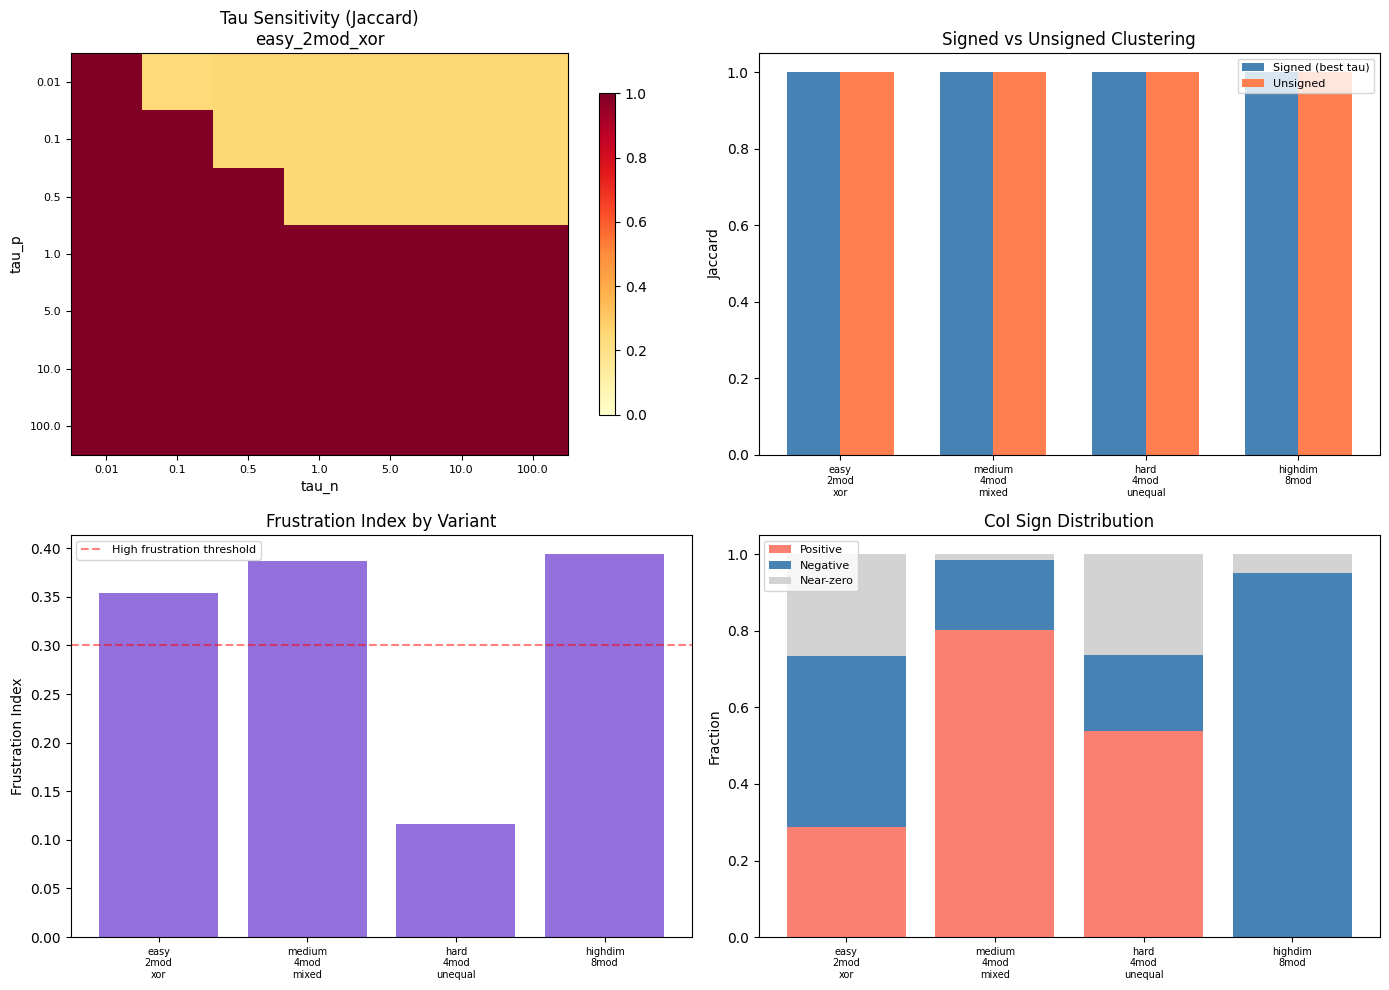

Visualization complete. Figure saved to diagnostic_results.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Tau sensitivity heatmap for first variant ────────────────────────
ax = axes[0, 0]
first_vname = list(tau_results.keys())[0]
tr = tau_results[first_vname]
hm = tr["heatmap_jaccard"]
im = ax.imshow(hm, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(TAU_VALUES)))
ax.set_xticklabels([str(t) for t in TAU_VALUES], fontsize=8)
ax.set_yticks(range(len(TAU_VALUES)))
ax.set_yticklabels([str(t) for t in TAU_VALUES], fontsize=8)
ax.set_xlabel('tau_n')
ax.set_ylabel('tau_p')
ax.set_title(f'Tau Sensitivity (Jaccard)\n{first_vname}')
plt.colorbar(im, ax=ax, shrink=0.8)

# ── Plot 2: Signed vs Unsigned Jaccard across variants ───────────────────────
ax = axes[0, 1]
vnames = list(per_variant.keys())
signed_jacs = [per_variant[v]["best_signed_jaccard"] for v in vnames]
unsigned_jacs = [per_variant[v]["best_unsigned_jaccard"] for v in vnames]
x = np.arange(len(vnames))
w = 0.35
ax.bar(x - w/2, signed_jacs, w, label='Signed (best tau)', color='steelblue')
ax.bar(x + w/2, unsigned_jacs, w, label='Unsigned', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([v.replace('_', '\n') for v in vnames], fontsize=7)
ax.set_ylabel('Jaccard')
ax.set_title('Signed vs Unsigned Clustering')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

# ── Plot 3: Frustration index across variants ────────────────────────────────
ax = axes[1, 0]
frusts = [decomp_results[v]["frustration_index"] for v in vnames if v in decomp_results]
frust_names = [v for v in vnames if v in decomp_results]
bars = ax.bar(range(len(frusts)), frusts, color='mediumpurple')
ax.set_xticks(range(len(frust_names)))
ax.set_xticklabels([v.replace('_', '\n') for v in frust_names], fontsize=7)
ax.set_ylabel('Frustration Index')
ax.set_title('Frustration Index by Variant')
ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='High frustration threshold')
ax.legend(fontsize=8)

# ── Plot 4: Sign distribution stacked bars ───────────────────────────────────
ax = axes[1, 1]
sign_data = []
for v in vnames:
    if v in decomp_results:
        sd = decomp_results[v]["sign_distribution"]
        sign_data.append((v, sd["frac_positive"], sd["frac_negative"], sd["frac_near_zero"]))

if sign_data:
    sd_names = [s[0] for s in sign_data]
    pos_fracs = [s[1] for s in sign_data]
    neg_fracs = [s[2] for s in sign_data]
    zero_fracs = [s[3] for s in sign_data]
    x2 = np.arange(len(sd_names))
    ax.bar(x2, pos_fracs, label='Positive', color='salmon')
    ax.bar(x2, neg_fracs, bottom=pos_fracs, label='Negative', color='steelblue')
    ax.bar(x2, zero_fracs, bottom=[p+n for p,n in zip(pos_fracs, neg_fracs)], label='Near-zero', color='lightgray')
    ax.set_xticks(x2)
    ax.set_xticklabels([v.replace('_', '\n') for v in sd_names], fontsize=7)
    ax.set_ylabel('Fraction')
    ax.set_title('CoI Sign Distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagnostic_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization complete. Figure saved to diagnostic_results.png")